<a href="https://www.kaggle.com/code/alaynac/nlp-movie-reviews-sentiment-analysis?scriptVersionId=338896512" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Step 1A: Load IMDB Movie Reviews Dataset

The dataset contains 50,000 movie reviews labeled as positive or negative.
Words are already encoded as integers based on frequency.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))
print("Sample review (as numbers):", x_train[0][:20])
print("Label (0=negative, 1=positive):", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Test samples: 25000
Sample review (as numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label (0=negative, 1=positive): 1


## Step 1B: Decode a Sample Review

Convert the integer-encoded review back to readable text to understand
the dataset.

In [3]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("Decoded review:")
print(decode_review(x_train[0]))
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Decoded review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are am

## Step 2: Preprocess Data and Build the Model

Pad all reviews to the same length, then build an LSTM-based neural
network for sentiment classification.

In [4]:
x_train_padded = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, 64),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(16)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-07-29 19:20:59.371922: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,289 (2.58 MB)

 Trainable params: 676,289 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train the Model

Train the Bidirectional LSTM model to classify reviews as positive or negative.

In [5]:
from tensorflow.keras import callbacks

EPOCHS = 10

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'nlp_sentiment_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    x_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6158 - loss: 0.6182
Epoch 1: val_accuracy improved from None to 0.84300, saving model to nlp_sentiment_best.keras

Epoch 1: finished saving model to nlp_sentiment_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 197ms/step - accuracy: 0.7286 - loss: 0.5184 - val_accuracy: 0.8430 - val_loss: 0.3676
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8886 - loss: 0.3041
Epoch 2: val_accuracy improved from 0.84300 to 0.86640, saving model to nlp_sentiment_best.keras

Epoch 2: finished saving model to nlp_sentiment_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 197ms/step - accuracy: 0.8858 - loss: 0.3034 - val_accuracy: 0.8664 - val_loss: 0.3578
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9239 - loss: 0.2148
Epoch 3: val_accuracy did not improve from 0.86640
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.9202 - loss: 0.2230 - val_accuracy: 0.8604 - val_loss: 0.3433
Epoch 4/10
157

## Step 4: Visualize Training History

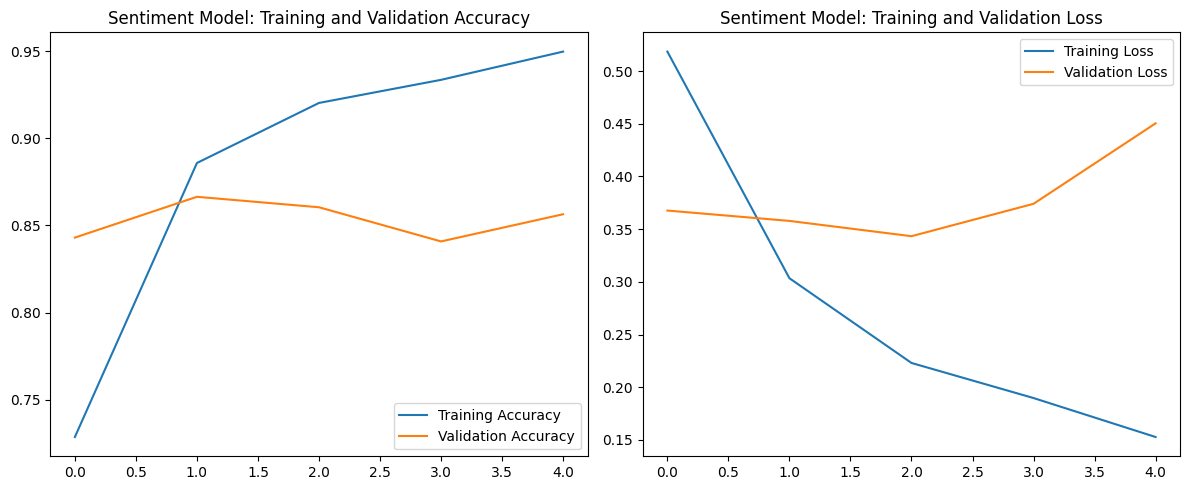

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Sentiment Model: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Sentiment Model: Training and Validation Loss')

plt.tight_layout()
plt.savefig('nlp_training_history.png')
plt.show()

## Step 5: Model Evaluation - Confusion Matrix & Classification Report

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step

Final Test Accuracy: 0.8512 (85.12%)
Final Test Loss: 0.3920

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85     12500
    Positive       0.85      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



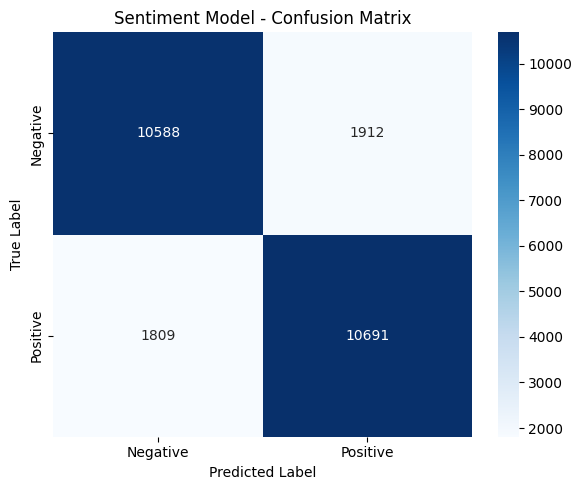

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(x_test_padded, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

test_loss, test_acc = model.evaluate(x_test_padded, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Sentiment Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('nlp_confusion_matrix.png')
plt.show()

## Step 6: Live Demo - Predict Sentiment of a Custom Review

Test the model on a new, custom-written review to see it classify
sentiment in real-time.

In [8]:
def predict_sentiment(review_text, model, word_index, max_len=MAX_LEN):
    words = review_text.lower().split()
    encoded = [word_index.get(word, 2) + 3 for word in words]
    padded = pad_sequences([encoded], maxlen=max_len, padding='post', truncating='post')

    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Review: \"{review_text}\"")
    print(f"Predicted Sentiment: {sentiment} ({confidence*100:.1f}% confidence)")
    return sentiment, confidence

# Try with your own custom reviews
predict_sentiment("This movie was absolutely fantastic, I loved every minute of it!", model, word_index)
print()
predict_sentiment("Terrible film, waste of time and money, very disappointing.", model, word_index)

Review: "This movie was absolutely fantastic, I loved every minute of it!"
Predicted Sentiment: Positive (90.5% confidence)

Review: "Terrible film, waste of time and money, very disappointing."
Predicted Sentiment: Negative (81.2% confidence)


('Negative', np.float32(0.8117266))

In [9]:
from IPython.display import FileLink
FileLink('nlp_sentiment_best.keras')

/kaggle/working/nlp_sentiment_best.keras